# Clasificación de imágenes de mascotas

En este proyecto se aborda el problema de clasificación de imágenes de mascotas utilizando el dataset Oxford-IIIT Pet, el cual contiene imágenes de diferentes razas de perros y gatos. Este problema representa un reto interesante debido a la alta similitud visual entre algunas clases y la variabilidad en condiciones como iluminación, pose y fondo.

## Contenido del dataset

* 37 clases (razas de perros y gatos)
* Aproximadamente 7,000 imágenes
* Alrededor de 200 imágenes por clase

Cada imagen incluye varias etiquetas:

* Raza del animal
* Categoria del animal ( perro o gato )
* Mascara pixel a pixel del animal
* Bounding box

El objetivo principal del trabajo es comparar el desempeño de diferentes arquitecturas de redes neuronales, incluyendo:

1. Una CNN base entrenada desde cero
2. Modelos preentrenados mediante transfer learning (MobileNetV2, ResNet50 y EfficientNetB0)

Para ello, se implementan técnicas clave como:

- Data augmentation
- Batch Normalization
- Regularización
- Pooling
- Early Stopping
- Transfer learning y fine-tuning

El desempeño de los modelos se evalúa mediante métricas como accuracy, precision, recall, F1-score y matrices de confusión, permitiendo un análisis detallado de su capacidad de generalización.

Finalmente, se selecciona el modelo más adecuado en función de su rendimiento y eficiencia computacional, proporcionando una solución robusta al problema planteado.

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [ ]:
(dataset_train, dataset_test), dataset_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

print(dataset_info)

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLab

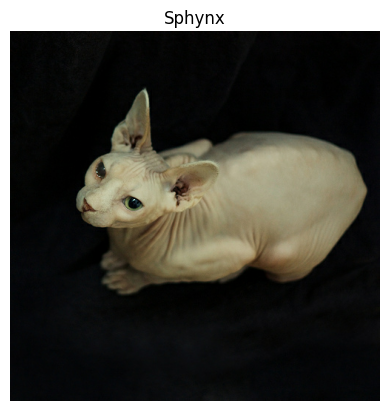

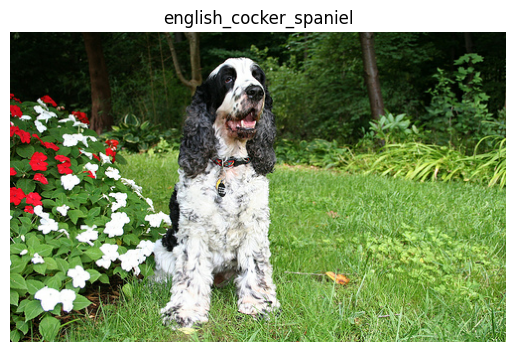

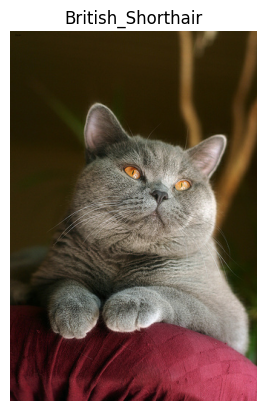

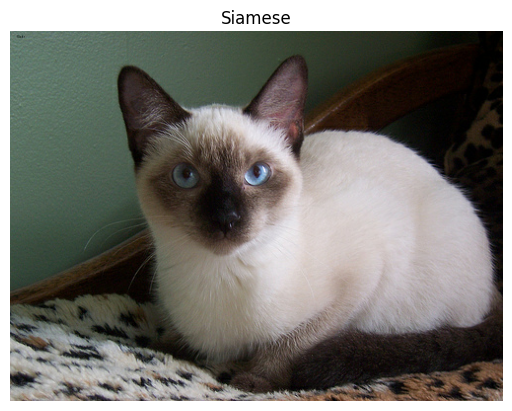

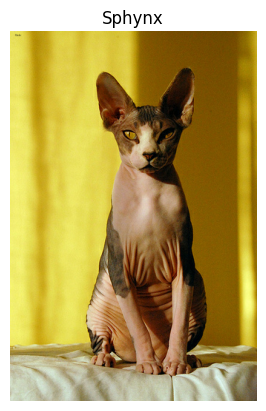

In [ ]:
label_names = dataset_info.features['label'].names

for image, label in dataset_train.take(5):
    plt.imshow(image)
    plt.title(label_names[label.numpy()])
    plt.axis("off")
    plt.show()

# CNN desde cero

Voy a crear una CNN desde cero para poder llevar a cabo la clasificacion de las imagenes.

Para ello, primero se definen los parámetros principales del pipeline de datos, incluyendo el tamaño de entrada de las imágenes y el tamaño de los lotes (batch size) para el entrenamiento.

Se define una función de preprocesamiento que redimensiona las imágenes a un tamaño fijo y normaliza los valores de los píxeles al rango [0,1], lo cual facilita el entrenamiento del modelo.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = (dataset_train
            .map(preprocess)
            .shuffle(1000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (dataset_test
           .map(preprocess)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

Defino mi modelo secuencial con 3 bloques convolucionales, regularizacion y su salida para 37 clases mediante una funcion de activacion softmax

In [ ]:
model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(37, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,429 (450.89 KB)

 Trainable params: 114,981 (449.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.0519 - loss: 3.6051 - val_accuracy: 0.0273 - val_loss: 3.8052
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - accuracy: 0.0745 - loss: 3.4715 - val_accuracy: 0.0303 - val_loss: 4.1152
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.0889 - loss: 3.3950 - val_accuracy: 0.0316 - val_loss: 4.5585
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.1068 - loss: 3.3229 - val_accuracy: 0.0417 - val_loss: 4.0089
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.1117 - loss: 3.2611 - val_accuracy: 0.0384 - val_loss: 3.8275
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.1443 - loss: 3.1640 - val_accuracy: 0.0736 - val_loss: 3.5609
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 296s 3s/step - accuracy: 0.1514 - loss: 3.0723 - val_accuracy: 0.0621 - val_loss: 4.0899
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.1758 - loss: 2.9624 - val_accu

Entreno mi modelo en 10 epocas con 114,981 parametros y los resultados no son muy buenos:
* Epoca 1 accuracy: 0.0440 - loss: 3.6079 - val_accuracy: 0.0273 - val_loss: 3.8476

* Epoca 10 accuracy: 0.2236 - loss: 2.7395 - val_accuracy: 0.1175 - val_loss: 3.3468

Para alimentar mas mi modelo decido aplicar data augmentation para aumentar la variabilidad del dataset mediante transformaciones aleatorias como rotación, volteo y zoom, lo que mejora la capacidad de generalización del modelo.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),])

In [ ]:
model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(37, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115,429 (450.89 KB)

 Trainable params: 114,981 (449.14 KB)

 Non-trainable params: 448 (1.75 KB)

En esta ocasion, implementé early stopping para evitar sobreentrenamiento, deteniendo el proceso cuando la pérdida de validación deja de mejorar y restaurando los mejores pesos del modelo

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    callbacks=[early_stop])

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 277s 2s/step - accuracy: 0.0437 - loss: 3.6239 - val_accuracy: 0.0281 - val_loss: 3.7757
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.0717 - loss: 3.4832 - val_accuracy: 0.0308 - val_loss: 4.1400
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.0853 - loss: 3.4007 - val_accuracy: 0.0401 - val_loss: 4.2927
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 269s 2s/step - accuracy: 0.1003 - loss: 3.3270 - val_accuracy: 0.0474 - val_loss: 3.6683
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.1139 - loss: 3.2494 - val_accuracy: 0.0695 - val_loss: 3.5067


Entreno el modelo nuevamente con los nuevos ajustes. Esta vez le pase early stopping con 20 epocas y continua arrojando resultados bastante pobres ya que con una pacience = 3 dejo de aprender en la epoca 11 con un accuracy de 0.18 y un loss de 2.90.

* Epoca 1 accuracy: 0.0543 - loss: 3.6055 - val_accuracy: 0.0270 - val_loss: 3.7731

* Epoca 11 accuracy: 0.1872 - loss: 2.9066 - val_accuracy: 0.0992 - val_loss: 3.5031

Genero las predicciones del modelo sobre el conjunto de prueba y almaceno tanto las etiquetas reales como las predichas para calcular métricas de evaluación. Posteriormente, esto sera empleado para evaluar el modelo y comparar entre ellos cual es el mejor.

In [ ]:
y_true_base = []
y_pred_base = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true_base.extend(labels.numpy())
    y_pred_base.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 561ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

En busqueda de un mejore desempeño, utilizare 3 backbones como extractores de características mediante transfer learning, congelando sus pesos y agregando un clasificador personalizado para adaptarlo al problema de clasificación de mascotas.

# Backbone 1: MobileNet

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128,128,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    layers.Input(shape=(128,128,3)),
    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(37, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,431,845 (9.28 MB)

 Trainable params: 171,301 (669.14 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4361 - loss: 2.0757 - val_accuracy: 0.7435 - val_loss: 0.8770
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 140s 984ms/step - accuracy: 0.6562 - loss: 1.1343 - val_accuracy: 0.7743 - val_loss: 0.7357
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 141s 981ms/step - accuracy: 0.6976 - loss: 0.9643 - val_accuracy: 0.7790 - val_loss: 0.7517
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 117s 992ms/step - accuracy: 0.7345 - loss: 0.8656 - val_accuracy: 0.7784 - val_loss: 0.7443
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 116s 993ms/step - accuracy: 0.7644 - loss: 0.7473 - val_accuracy: 0.7762 - val_loss: 0.7583
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7696 - loss: 0.6948 - val_accuracy: 0.7708 - val_loss: 0.7908
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 140s 987ms/step - accuracy: 0.8011 - loss: 0.6148 - val_accuracy: 0.7814 - val_loss: 0.7911
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 116s 981ms/step - accuracy: 0.8084 - loss:

Aplicare fine-tuning descongelando parcialmente las capas superiores del modelo preentrenado y utilizando un learning rate bajo para adaptar las features al dominio específico.

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.6870 - loss: 1.0174 - val_accuracy: 0.7942 - val_loss: 0.7133
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.7228 - loss: 0.8707 - val_accuracy: 0.7937 - val_loss: 0.7099
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.7538 - loss: 0.7857 - val_accuracy: 0.7975 - val_loss: 0.7032
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.7601 - loss: 0.7475 - val_accuracy: 0.8002 - val_loss: 0.6948
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.7769 - loss: 0.7003 - val_accuracy: 0.8010 - val_loss: 0.6934


In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

Utilizando metricas como precision, recall y f1-score evaluo cual fue el desempeño de este nuevo modelo.

In [ ]:
report = classification_report(y_true, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.74      0.69      0.72        98
           1       0.67      0.78      0.72       100
           2       0.50      0.60      0.55       100
           3       0.89      0.79      0.84       100
           4       0.83      0.78      0.80       100
           5       0.84      0.76      0.80       100
           6       0.61      0.69      0.65       100
           7       0.94      0.74      0.83        88
           8       0.79      0.78      0.78        99
           9       0.70      0.80      0.74       100
          10       0.76      0.61      0.68       100
          11       0.87      0.81      0.84        97
          12       0.85      0.77      0.81       100
          13       0.75      0.80      0.78       100
          14       0.86      0.90      0.88       100
          15       0.84      0.95      0.89       100
          16       0.86      0.83      0.84       100
          17       0.95    

In [ ]:
report = classification_report(y_true, y_pred, output_dict=True)

print("Precision promedio:", report["weighted avg"]["precision"])
print("Recall promedio:", report["weighted avg"]["recall"])
print("F1-score promedio:", report["weighted avg"]["f1-score"])

Precision promedio: 0.8085978933732476
Recall promedio: 0.801035704551649
F1-score promedio: 0.8016518772167648


Aplico una matriz de confusion normalizada para visualizar mejor la evaluacion de mi modelo

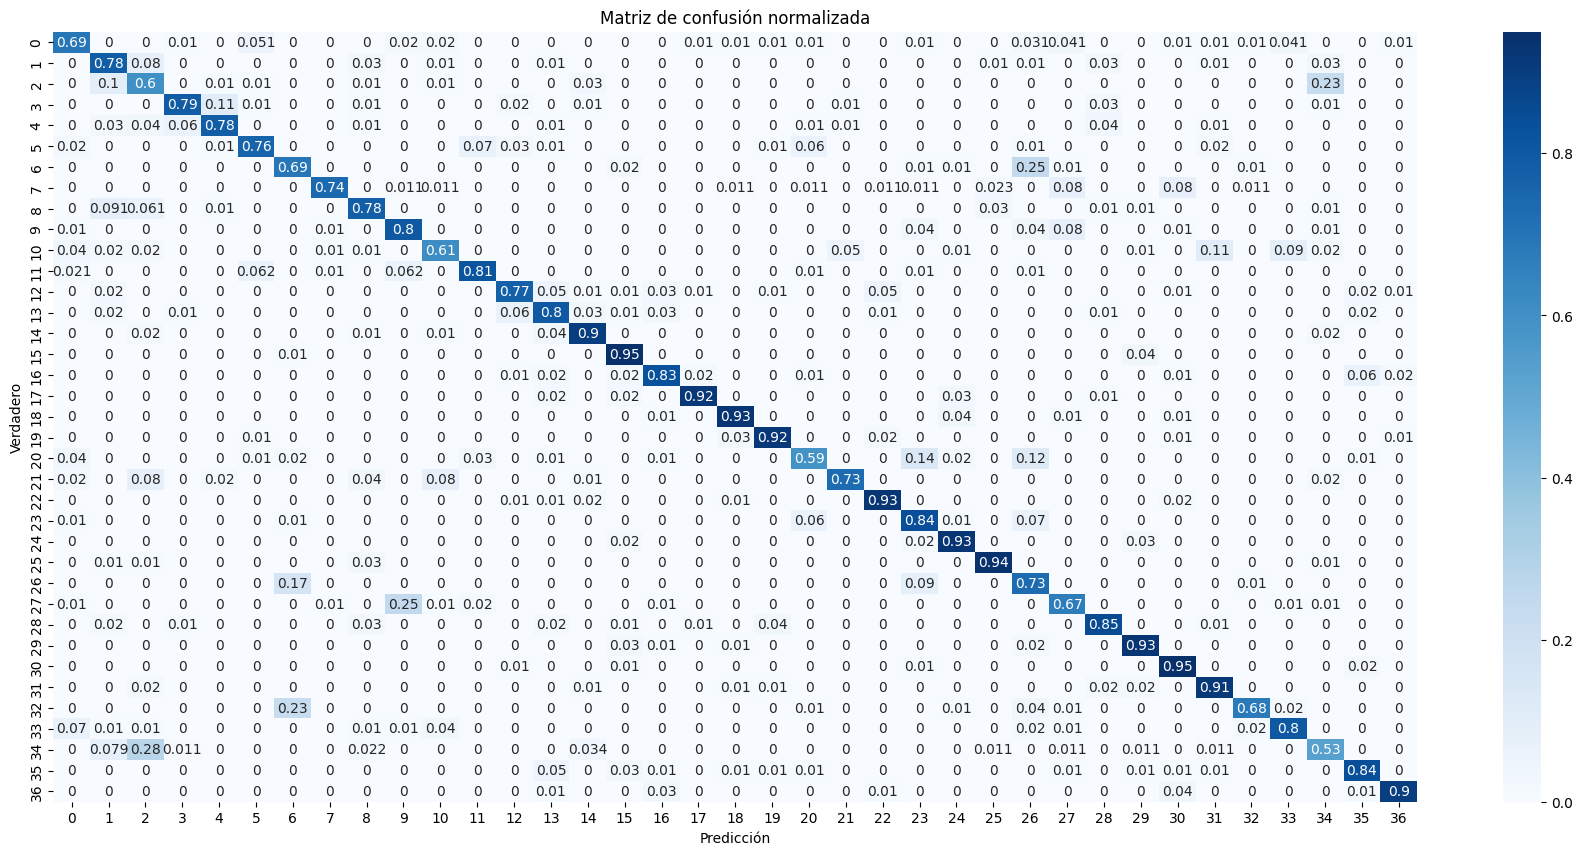

In [ ]:
cm = confusion_matrix(y_true, y_pred)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(22,10))
sns.heatmap(cm_norm, cmap='Blues', annot=True)
plt.title('Matriz de confusión normalizada')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Backbone 2: EfficientNet

In [ ]:
(dataset_train, dataset_test), dataset_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    with_info=True,
    as_supervised=True
)

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess_effnet(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)
    return image, label

train_ds = (dataset_train
            .map(preprocess_effnet)
            .shuffle(1000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

test_ds = (dataset_test
           .map(preprocess_effnet)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_eff = models.Sequential([
    layers.Input(shape=(224,224,3)),
    data_augmentation,
    layers.Lambda(tf.keras.applications.efficientnet.preprocess_input),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(37, activation='softmax')
])

model_eff.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,223,432 (16.11 MB)

 Trainable params: 171,301 (669.14 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
history_eff = model_eff.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 566s 5s/step - accuracy: 0.6519 - loss: 1.2688 - val_accuracy: 0.8945 - val_loss: 0.6149
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 564s 5s/step - accuracy: 0.8459 - loss: 0.4894 - val_accuracy: 0.9002 - val_loss: 0.3242
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 553s 5s/step - accuracy: 0.8728 - loss: 0.3818 - val_accuracy: 0.9084 - val_loss: 0.2879
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 560s 5s/step - accuracy: 0.9041 - loss: 0.2897 - val_accuracy: 0.9024 - val_loss: 0.3057
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 557s 5s/step - accuracy: 0.9111 - loss: 0.2612 - val_accuracy: 0.9084 - val_loss: 0.3091
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 555s 5s/step - accuracy: 0.9264 - loss: 0.2220 - val_accuracy: 0.9038 - val_loss: 0.3293
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 550s 5s/step - accuracy: 0.9312 - loss: 0.2024 - val_accuracy: 0.8978 - val_loss: 0.3366
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 564s 5s/step - accuracy: 0.9408 - loss: 0.1610 - val_accu

In [ ]:
y_true_eff = []
y_pred_eff = []

for images, labels in test_ds:
    preds = model_eff.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true_eff.extend(labels.numpy())
    y_pred_eff.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

In [ ]:
label_names = dataset_info.features['label'].names

print(classification_report(
    y_true_eff,
    y_pred_eff,
    target_names=label_names
))

                            precision    recall  f1-score   support

                Abyssinian       0.96      0.83      0.89        98
          american_bulldog       0.81      0.86      0.83       100
 american_pit_bull_terrier       0.88      0.42      0.57       100
              basset_hound       0.96      0.93      0.94       100
                    beagle       0.89      0.92      0.91       100
                    Bengal       0.80      0.71      0.75       100
                    Birman       0.69      0.85      0.76       100
                    Bombay       0.93      0.95      0.94        88
                     boxer       0.84      0.91      0.87        99
         British_Shorthair       0.83      0.85      0.84       100
                 chihuahua       0.92      0.88      0.90       100
              Egyptian_Mau       0.83      0.93      0.87        97
    english_cocker_spaniel       0.99      0.94      0.96       100
            english_setter       0.97      0.99

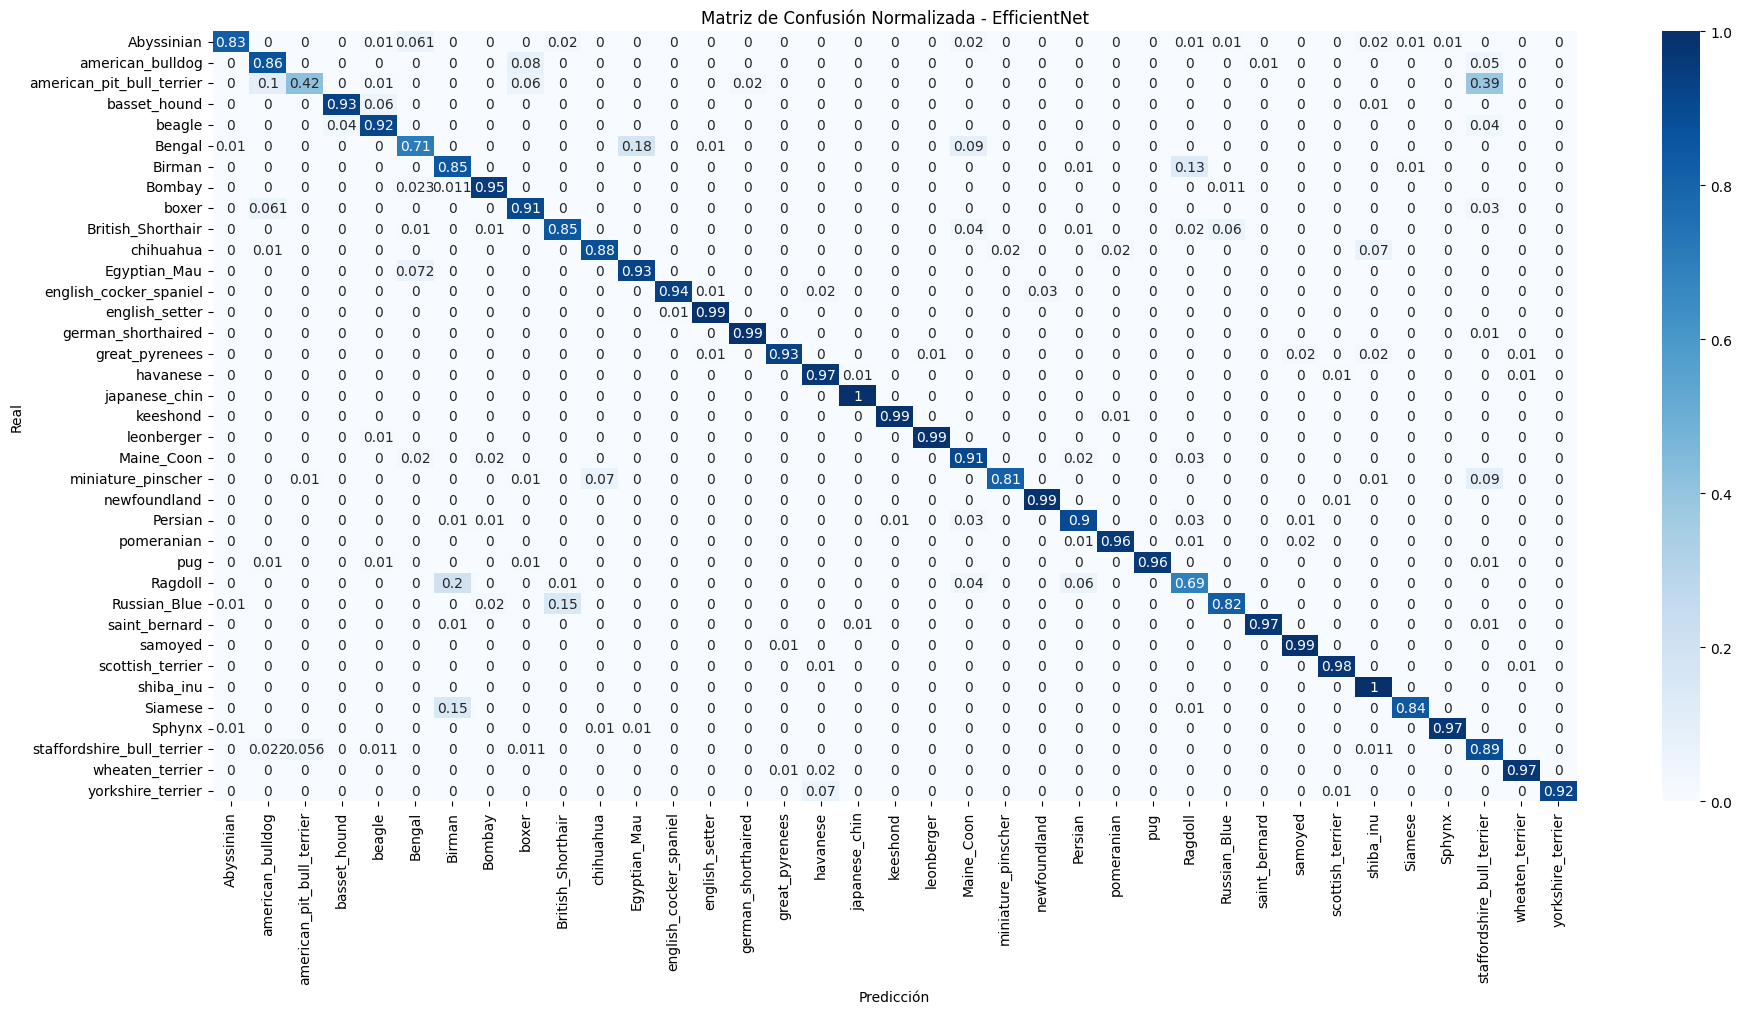

In [ ]:
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

cm_eff_norm = cm_eff.astype('float') / cm_eff.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(22,10))

sns.heatmap(
    cm_eff_norm,
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Blues',
    annot=True
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Matriz de Confusión Normalizada - EfficientNet")

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

# Backbone 3: ResNet

In [ ]:
def preprocess_resnet(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.cast(image, tf.float32)  # ❗ sin /255
    return image, label

train_ds_res = (dataset_train
                .map(preprocess_resnet)
                .shuffle(1000)
                .batch(BATCH_SIZE)
                .prefetch(tf.data.AUTOTUNE))

test_ds_res = (dataset_test
               .map(preprocess_resnet)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model_res = tf.keras.applications.ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model_res.trainable = False

model_res = models.Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Lambda(tf.keras.applications.resnet50.preprocess_input),

    base_model_res,

    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(37, activation='softmax')
])

model_res.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_res.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_9 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,862,949 (91.03 MB)

 Trainable params: 271,141 (1.03 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

El modelo arrojo muchos parametros y es muy robusto por los cual decido entrenar solo con 3 epocas.

In [ ]:
history_res = model_res.fit(
    train_ds_res,
    validation_data=test_ds_res,
    epochs=3
)

Epoch 1/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 1398s 12s/step - accuracy: 0.6117 - loss: 1.4351 - val_accuracy: 0.8288 - val_loss: 0.5625
Epoch 2/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 1352s 12s/step - accuracy: 0.8364 - loss: 0.5254 - val_accuracy: 0.8490 - val_loss: 0.4903
Epoch 3/3
115/115 ━━━━━━━━━━━━━━━━━━━━ 1341s 12s/step - accuracy: 0.8750 - loss: 0.3840 - val_accuracy: 0.8490 - val_loss: 0.5218


In [ ]:
y_true_res = []
y_pred_res = []

for images, labels in test_ds_res:
    preds = model_res.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true_res.extend(labels.numpy())
    y_pred_res.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 18s 18s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6

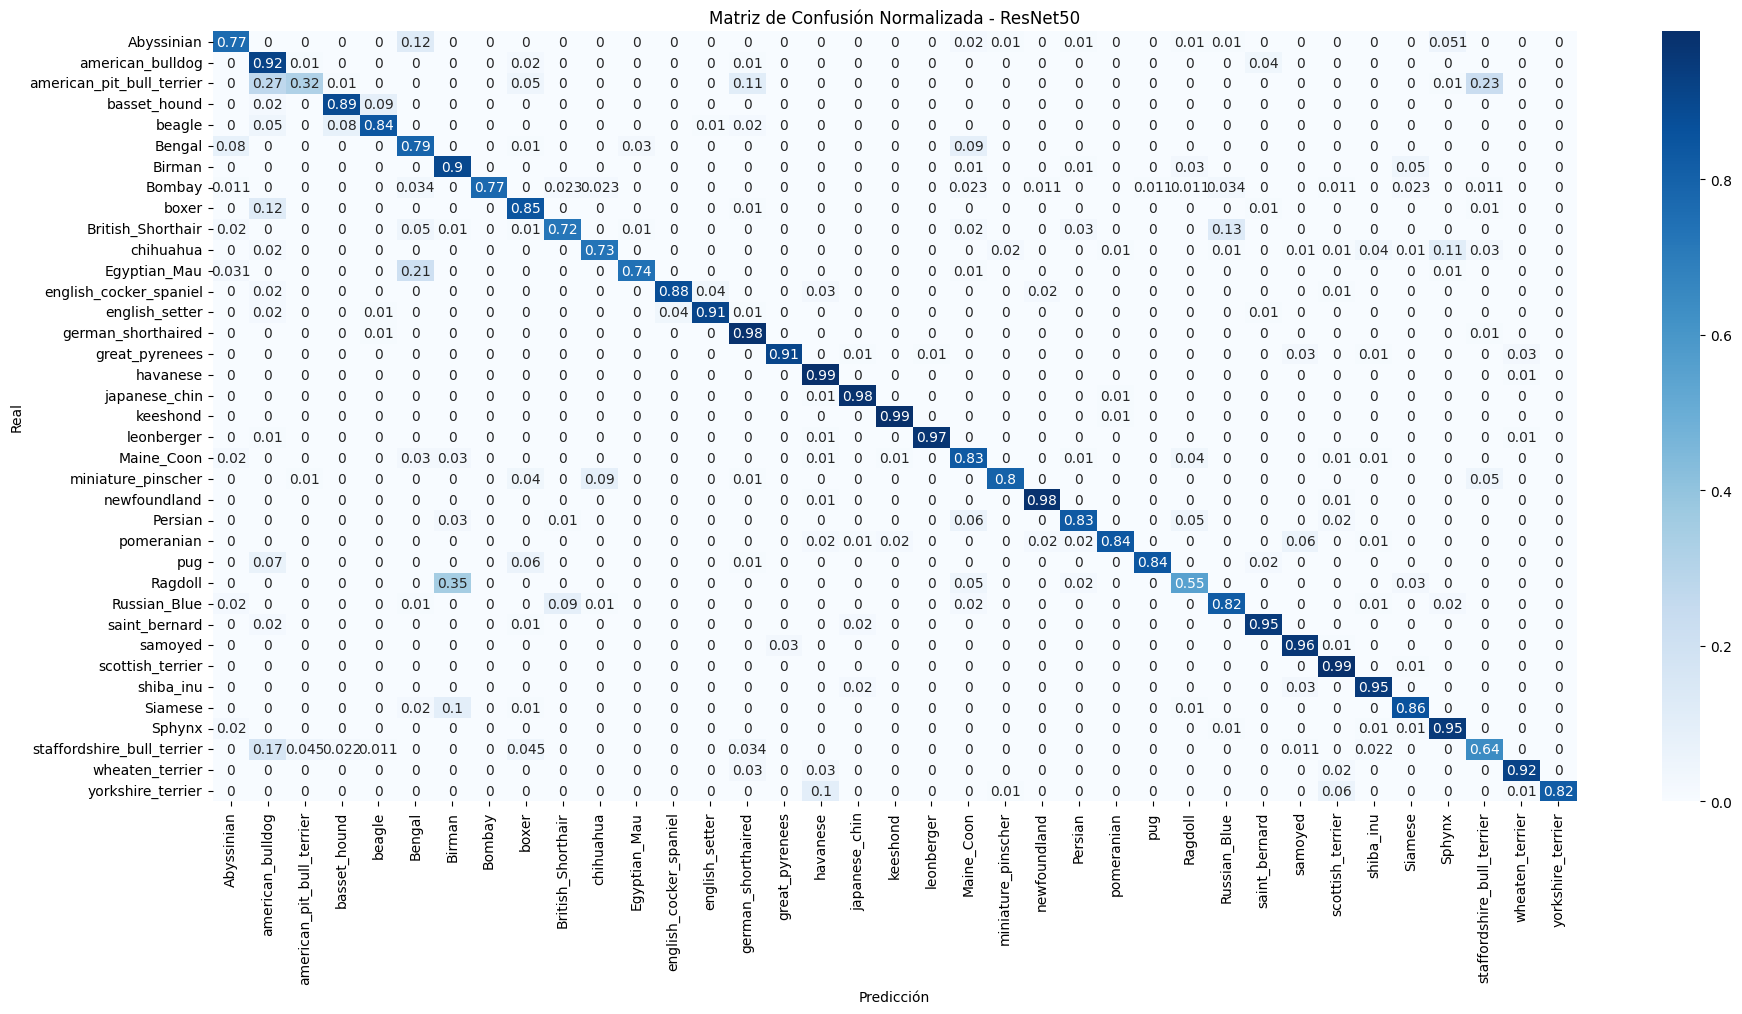

In [ ]:
cm_res = confusion_matrix(y_true_res, y_pred_res)

cm_res_norm = cm_res.astype('float') / cm_res.sum(axis=1)[:, np.newaxis]

label_names = dataset_info.features['label'].names

plt.figure(figsize=(22,10))
sns.heatmap(
    cm_res_norm,
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Blues',
    annot=True
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title("Matriz de Confusión Normalizada - ResNet50")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

# Cuadro comparativo de los 4 modelos empleados

In [ ]:
print("CNN Base Accuracy:", accuracy_score(y_true_base, y_pred_base))
print("MobileNet Accuracy:", accuracy_score(y_true, y_pred))
print("EfficientNet Accuracy:", accuracy_score(y_true_eff, y_pred_eff))
print("ResNet Accuracy:", accuracy_score(y_true_res, y_pred_res))

CNN Base Accuracy: 0.06950122649223221
MobileNet Accuracy: 0.801035704551649
EfficientNet Accuracy: 0.902698282910875
ResNet Accuracy: 0.8490051785227583


# Conclusion Final

El desarrollo de este proyecto permitió evaluar de manera integral el desempeño de distintas arquitecturas de redes neuronales convolucionales en la tarea de clasificación de imágenes del dataset Oxford-IIIT Pet. A través de la implementación progresiva de modelos —desde una CNN base hasta arquitecturas avanzadas con transfer learning— se evidenció claramente el impacto de utilizar modelos preentrenados en problemas de visión por computador.

Los resultados obtenidos muestran que la CNN entrenada desde cero presenta un desempeño limitado, debido principalmente a la cantidad de datos disponible y a la complejidad del problema. En contraste, los modelos basados en transfer learning (MobileNetV2, ResNet50 y EfficientNetB0) lograron mejoras significativas en términos de precisión y capacidad de generalización.

Entre los modelos evaluados, EfficientNetB0 se destacó como la mejor alternativa, alcanzando el mayor accuracy en validación (alrededor de 90%) y mostrando un equilibrio óptimo entre rendimiento y eficiencia computacional. Aunque ResNet50 también obtuvo resultados competitivos (alrededor de 85%), su mayor número de parámetros y tendencia al sobreajuste lo hacen menos eficiente en comparación. Por su parte, MobileNetV2 ofreció un desempeño aceptable (alrededor de 79%), destacándose como una opción ligera para escenarios con restricciones de recursos.

El análisis mediante métricas adicionales como precision, recall y F1-score, junto con la matriz de confusión, permitió identificar que los principales errores del modelo están asociados a clases con alta similitud visual, lo cual es consistente con la naturaleza del dataset. A pesar de ello, el modelo final mantiene un alto nivel de precisión en la mayoría de las categorías.

Adicionalmente, se comprobó la importancia de aplicar correctamente técnicas como data augmentation, batch normalization, regularización y preprocessing específico por arquitectura, siendo este último un factor crítico para el correcto funcionamiento de modelos preentrenados.

En conclusión, este proyecto demuestra que la combinación de transfer learning con buenas prácticas de entrenamiento permite construir modelos altamente efectivos incluso en datasets de tamaño moderado. Asimismo, resalta la importancia de comparar múltiples arquitecturas y tomar decisiones basadas en métricas objetivas, enfoque fundamental en el desarrollo de soluciones reales de Machine Learning.